# Sandbox Notebook: Class-based Multi-day Solver Run

Этот ноутбук **сам запускает алгоритм**:
- генерирует дневные данные из базового dataset,
- гоняет solver по дням,
- рисует красивую карту за первый день,
- собирает метрики по всем дням.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path

base = Path('/content/drive/MyDrive/Colab Notebooks/opti')
print(base.exists())
print(list(base.iterdir()))

True
[PosixPath('/content/drive/MyDrive/Colab Notebooks/opti/dataset_sandbox_type2.json'), PosixPath('/content/drive/MyDrive/Colab Notebooks/opti/opti.ipynb"'), PosixPath('/content/drive/MyDrive/Colab Notebooks/opti/runtime_outputs'), PosixPath('/content/drive/MyDrive/Colab Notebooks/opti/simple_solver_min.py'), PosixPath('/content/drive/MyDrive/Colab Notebooks/opti/simple_solver_components.py'), PosixPath('/content/drive/MyDrive/Colab Notebooks/opti/dataset.py'), PosixPath('/content/drive/MyDrive/Colab Notebooks/opti/sandbox_data_pack_my.ipynb'), PosixPath('/content/drive/MyDrive/Colab Notebooks/opti/Untitled'), PosixPath('/content/drive/MyDrive/Colab Notebooks/opti/solver_py.py'), PosixPath('/content/drive/MyDrive/Colab Notebooks/opti/solver.py'), PosixPath('/content/drive/MyDrive/Colab Notebooks/opti/Untitled0.ipynb'), PosixPath('/content/drive/MyDrive/Colab Notebooks/opti/__pycache__'), PosixPath('/content/drive/MyDrive/Colab Notebooks/opti/simple_solver.py'), PosixPath('/content/d

In [3]:
import os, sys
from pathlib import Path

NOTEBOOK_DIR = Path("/content/drive/MyDrive/Colab Notebooks/opti")
BASE_DATASET_PATH = NOTEBOOK_DIR / "dataset_sandbox_type2.json"

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import simple_solver as solver
from dataset import dataset_from_dict

BASE_DATASET_PATH

PosixPath('/content/drive/MyDrive/Colab Notebooks/opti/dataset_sandbox_type2.json')

In [4]:
from __future__ import annotations

from dataclasses import dataclass
from copy import deepcopy
from collections import defaultdict
from pathlib import Path
import json
import random
import sys
from typing import Any

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

NOTEBOOK_DIR = Path.cwd().resolve()
BASE_DATASET_PATH = NOTEBOOK_DIR / "dataset_sandbox_type2.json"

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import simple_solver as solver
from dataset import dataset_from_dict

BASE_DATASET_PATH


PosixPath('/content/dataset_sandbox_type2.json')

## Классы: Предобработка И Запуск Solving

In [5]:
@dataclass
class DayResult:
    day_index: int
    solver_status: str
    assigned_routes: int
    unassigned_tasks: int
    active_agents: int
    transport_work_ton_km: float | None
    all_checks_ok: bool
    output_dir: Path


class DayPayloadFactory:
    def __init__(self, base_payload: dict[str, Any]) -> None:
        self.base_payload = base_payload

    def build(self, day_index: int, *, seed: int, mass_noise: float) -> dict[str, Any]:
        rng = random.Random(seed + day_index * 10007)
        payload = deepcopy(self.base_payload)

        mass_by_source: dict[str, float] = defaultdict(float)
        for task in payload["tasks"]:
            mass = float(task["mass_tons"])
            factor = 1.0 + rng.uniform(-mass_noise, mass_noise)
            adj = max(0.05, mass * factor)
            task["mass_tons"] = round(adj, 3)
            mass_by_source[task["source_node_id"]] += adj

        for node in payload["graph"]["nodes"]:
            if node["kind"] == "mno":
                node["daily_mass_tons"] = round(mass_by_source.get(node["node_id"], 0.0), 3)

        metadata = payload.setdefault("metadata", {})
        metadata["day_index"] = day_index
        metadata["name"] = f"{metadata.get('name', 'sandbox')}_day_{day_index:03d}"
        return payload


class MultiDaySandboxRunner:
    def __init__(self, base_dataset_path: Path, output_root: Path) -> None:
        self.base_dataset_path = base_dataset_path
        self.output_root = output_root
        self.output_root.mkdir(parents=True, exist_ok=True)

        self.base_payload = json.loads(self.base_dataset_path.read_text(encoding="utf-8"))
        self.factory = DayPayloadFactory(self.base_payload)

    def solve_day(self, day_payload: dict[str, Any], *, render_map: bool) -> DayResult:
        day_index = int(day_payload.get("metadata", {}).get("day_index", 0))
        day_dir = self.output_root / f"day_{day_index:03d}"
        day_dir.mkdir(parents=True, exist_ok=True)

        dataset = dataset_from_dict(day_payload)
        dataset.validate()

        graph = solver.build_nx_graph(dataset)
        cache: dict[tuple[str, str], tuple[list[str], float] | None] = {}
        reachability = solver.check_reachability(graph, dataset, cache)
        routes, states, unassigned = solver.assign_tasks_greedy(dataset, graph, day_payload, cache)

        solver_status = "infeasible"
        limit_violations: list[dict[str, Any]] = []
        transport_work = None
        solved_dataset_valid = False
        if not unassigned:
            solved_dataset = solver.build_solution_dataset(dataset, routes)
            solved_dataset_valid = True
            limit_violations = solver.validate_daily_limits(states)
            if not limit_violations:
                solver_status = "feasible"
            transport_work = round(solved_dataset.transport_work(), 3)

        checks = solver.constraints_check_summary(
            solved_dataset_valid=solved_dataset_valid,
            limit_violations=limit_violations,
            reachability=reachability,
            unassigned=unassigned,
            mno_coverage=solver.mno_scope_coverage_summary(dataset, routes),
        )

        # JSON artifacts per day (no md)
        plan = solver.build_solution_plan(routes, dataset, states)
        (day_dir / "solution_plan.json").write_text(json.dumps(plan, ensure_ascii=False, indent=2), encoding="utf-8")
        (day_dir / "feasibility_report.json").write_text(
            json.dumps(
                {
                    "solver_status": solver_status,
                    "constraints_check_summary": checks,
                    "assigned_routes": len(routes),
                    "unassigned_tasks": unassigned,
                    "active_agents": sum(1 for s in states.values() if s.task_ids),
                    "transport_work_ton_km": transport_work,
                },
                ensure_ascii=False,
                indent=2,
            ),
            encoding="utf-8",
        )

        if render_map:
            solver.render_solution_map(dataset, graph, cache, routes, states, day_dir / "solution_map.png")
            solver.render_utilization(states, day_dir / "agent_utilization.png")

        return DayResult(
            day_index=day_index,
            solver_status=solver_status,
            assigned_routes=len(routes),
            unassigned_tasks=len(unassigned),
            active_agents=sum(1 for s in states.values() if s.task_ids),
            transport_work_ton_km=transport_work,
            all_checks_ok=bool(checks.get("all_checks_ok", False)),
            output_dir=day_dir,
        )

    def run(self, *, days: int, seed: int = 42, mass_noise: float = 0.08, render_first_day: bool = True) -> list[DayResult]:
        results: list[DayResult] = []
        for day in range(1, days + 1):
            payload = self.factory.build(day, seed=seed, mass_noise=mass_noise)
            result = self.solve_day(payload, render_map=(render_first_day and day == 1))
            results.append(result)
        return results


## Запуск На Несколько Дней

In [6]:
NOTEBOOK_DIR = Path("/content/drive/MyDrive/Colab Notebooks/opti")
OUTPUT_ROOT = NOTEBOOK_DIR / "runtime_outputs"
BASE_DATASET_PATH = NOTEBOOK_DIR / "dataset_sandbox_type2.json"

runner = MultiDaySandboxRunner(BASE_DATASET_PATH, OUTPUT_ROOT)
results = runner.run(days=7, seed=42, mass_noise=0.08, render_first_day=True)

for r in results:
    print(r)


DayResult(day_index=1, solver_status='feasible', assigned_routes=18, unassigned_tasks=0, active_agents=16, transport_work_ton_km=149.544, all_checks_ok=True, output_dir=PosixPath('/content/drive/MyDrive/Colab Notebooks/opti/runtime_outputs/day_001'))
DayResult(day_index=2, solver_status='feasible', assigned_routes=18, unassigned_tasks=0, active_agents=18, transport_work_ton_km=148.562, all_checks_ok=True, output_dir=PosixPath('/content/drive/MyDrive/Colab Notebooks/opti/runtime_outputs/day_002'))
DayResult(day_index=3, solver_status='feasible', assigned_routes=18, unassigned_tasks=0, active_agents=16, transport_work_ton_km=152.56, all_checks_ok=True, output_dir=PosixPath('/content/drive/MyDrive/Colab Notebooks/opti/runtime_outputs/day_003'))
DayResult(day_index=4, solver_status='feasible', assigned_routes=18, unassigned_tasks=0, active_agents=17, transport_work_ton_km=149.82, all_checks_ok=True, output_dir=PosixPath('/content/drive/MyDrive/Colab Notebooks/opti/runtime_outputs/day_004')

## Метрики По Дням

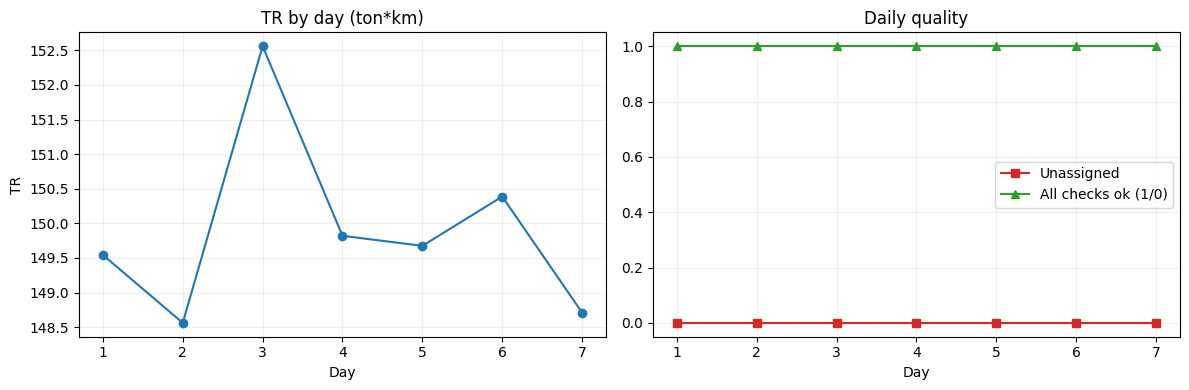

In [7]:
days = [r.day_index for r in results]
tr = [r.transport_work_ton_km or 0.0 for r in results]
unassigned = [r.unassigned_tasks for r in results]
checks = [1 if r.all_checks_ok else 0 for r in results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(days, tr, marker="o", color="#1f77b4")
axes[0].set_title("TR by day (ton*km)")
axes[0].set_xlabel("Day")
axes[0].set_ylabel("TR")
axes[0].grid(alpha=0.2)

axes[1].plot(days, unassigned, marker="s", color="#d62728", label="Unassigned")
axes[1].plot(days, checks, marker="^", color="#2ca02c", label="All checks ok (1/0)")
axes[1].set_title("Daily quality")
axes[1].set_xlabel("Day")
axes[1].grid(alpha=0.2)
axes[1].legend()

plt.tight_layout()
plt.show()


## Красивая Отрисовка За Первый День

Day 1 map: /content/drive/MyDrive/Colab Notebooks/opti/runtime_outputs/day_001/solution_map.png


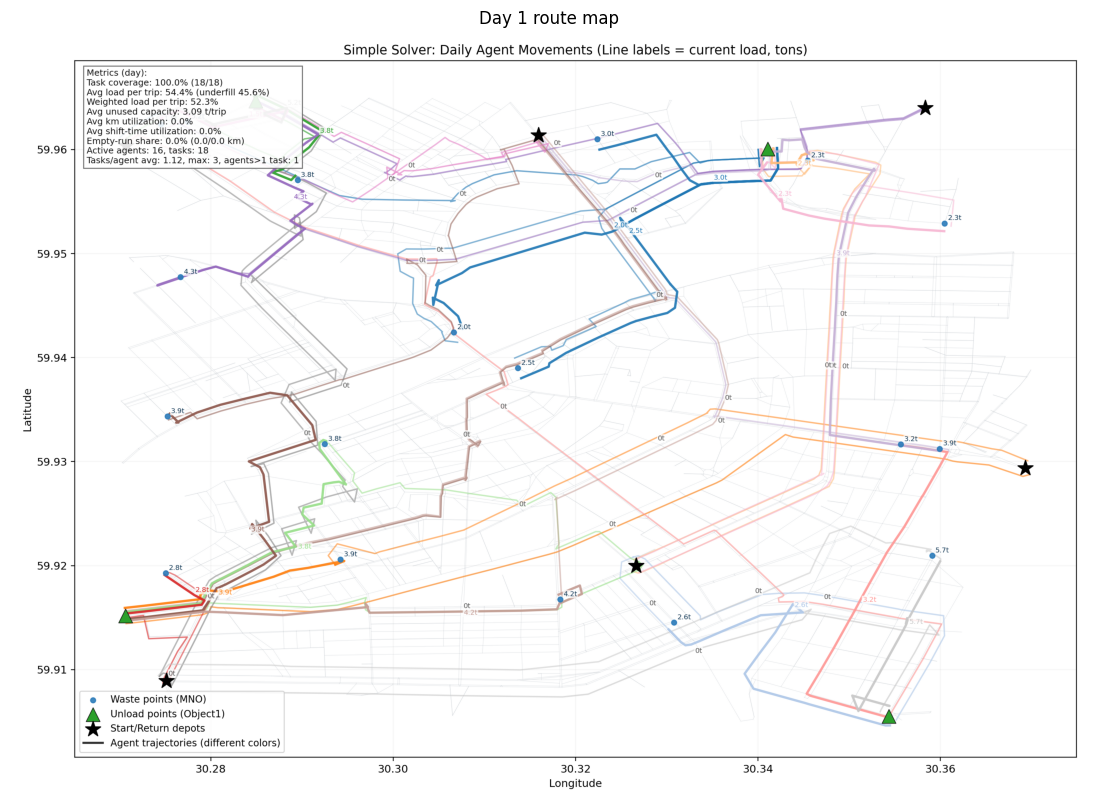

In [8]:
day1_map = OUTPUT_ROOT / "day_001" / "solution_map.png"
print("Day 1 map:", day1_map)

img = mpimg.imread(day1_map)
plt.figure(figsize=(14, 10))
plt.imshow(img)
plt.axis("off")
plt.title("Day 1 route map")
plt.show()
